# Projeto 4 - Álgebra Linear Numérica

# Questão 1

## Item a)
Para obtermos um vetor na direção de $e_1$ com a mesma norma de $x$, queremos refletir $x$ pelo hiperplano ortogonal a $v = x - \lVert x \rVert e_1$, porque esse hiperplano é a mediatriz de $x$ e $e_1$. 

Nesse caso, a lógica para refletir é a mesma que para projetar! Se nosso projetor  $I - \frac{vv*}{v*v}$ projeta sobre o espaço ortogonal, então subtrair $\frac{vv*}{v*v}x$ de $x$ leva ao espaço ortogonal e, portanto, subtrair $2\frac{vv*}{v*v}x$ "atravessa" esse espaço e chega "do outro lado", na reflexão de $x$ pelo hiperplano. Essa reflexão é, justamente, o vetor $||x||e_1$. Assim, nosso refletor será $Q_v = I - \beta v v^*$.
$$Q_v x = \lVert x \rVert e_1 \iff (I - \beta v v^*) x = \lVert x \rVert e_1 \iff x  - \beta v v^* x= \lVert x \rVert e_1$$
$$\beta v v^* x = x - \lVert x \rVert e_1 \iff (\beta v^* x) v = x - \lVert x \rVert e_1 \iff \beta v^* x = 1$$
$$\beta = \frac{1}{v^* x} \iff \beta = \frac{1}{(x - \lVert x \rVert e_1)^* x} \iff \beta = \frac{1}{(x^* - \lVert x \rVert e_1^*) x}$$
$$\beta = \frac{1}{x^* x - \lVert x \rVert e_1^* x} \iff \beta = \frac{1}{\lVert x \rVert^2 - \lVert x \rVert x_1} \iff \beta = \frac{1}{\lVert x \rVert(\lVert x \rVert - x_1)}$$

# Item b)

No caso em que $x_1$ é positivo, podemos enfrentar problemas ao computar $\frac{1}{\lVert x \rVert(\lVert x \rVert - x_1)}$ porque, se $x$ for muito próximo de $e_1$, $x_1 \approx \lVert x \rVert$ e o termo $\lVert x \rVert - x_1$ pode ficar muito próximo de $0$, o que faria com que $\beta$ "explodisse". Nesse caso, não enfrentamos o mesmo problema com a fórmula $\frac{\lVert x \rVert + x_1}{\lVert x \rVert \cdot \lVert y \rVert}$ porque estamos somando apenas quantidades positivas! 

O exato oposto é válido quando $x$ é negativo: $x$ muito próximo de $e_1$ torna $- x_1 \approx \lVert x \rVert$ e o termo $\lVert x \rVert + x_1$ pode ficar muito próximo de $0$, causando erros para $\frac{\lVert x \rVert + x_1}{\lVert x \rVert \cdot \lVert y \rVert}$, mas não enfrentamos esse problema computando  $\frac{1}{\lVert x \rVert(\lVert x \rVert - x_1)}$

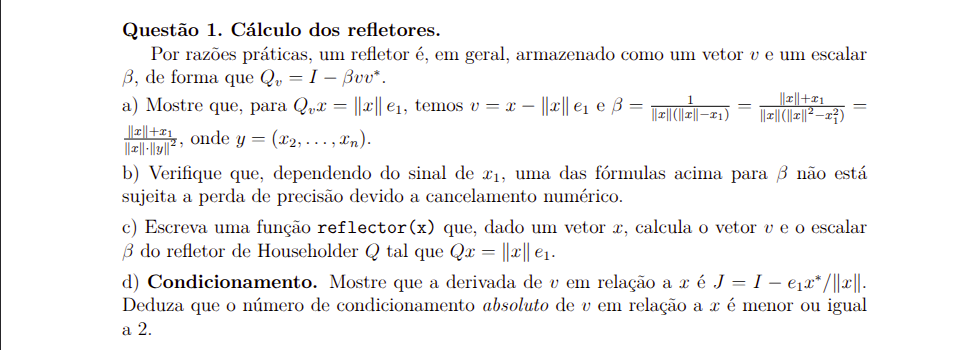

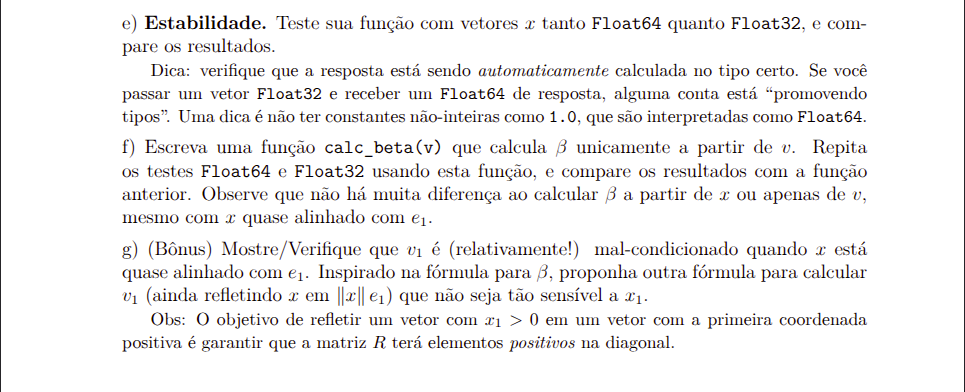

# Questão 2

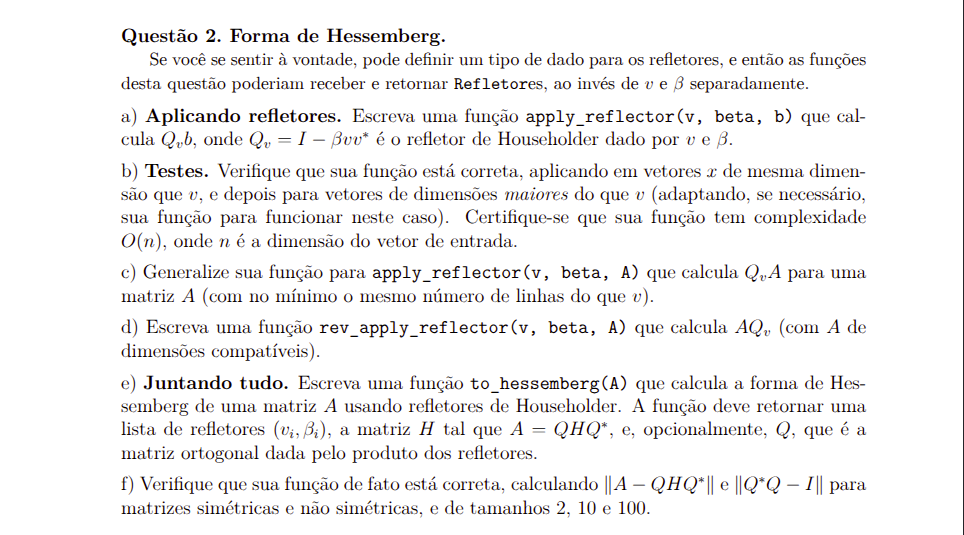

## Item a)

In [1]:
using LinearAlgebra

In [2]:
struct Refletores{T<:Number}
    v::Vector
    beta::T
    dim::Int

    function Refletores(v::Vector, beta::T) where {T<:Number}
        dim = length(v)
        new{T}(v, beta, dim)
    end
    
end

r = Refletores([1, 0, 0], 2)
r.dim

3

In [3]:
function apply_reflector!(ref::Refletores, b::Vector)
    @views b[1:ref.dim] .-= ref.beta .* ref.v .*(ref.v ⋅ b[1:ref.dim])
    return b
end

apply_reflector! (generic function with 1 method)

## Item b)

Para testar nossa função, vamos comparar os resultados com a função `reflectorApply` da biblioteca `LinearAlgebra`.

In [ ]:
for i in 1:100:1000
    
    r = Refletores(rand(i), rand())
    b = rand(i)
    a = deepcopy(b)

    apply_reflector!(r, b)
    LinearAlgebra.reflectorApply!(r.v, r.beta, a)
    @show norm(a - b)
end

for i in 1:100:1000    
        r = Refletores(rand(i), rand())
        b = rand(i)
        a = deepcopy(b)

        apply_reflector!(r, b)
        LinearAlgebra.reflectorApply!(r.v, r.beta, a)
        @show norm(a - b[1:i])
end


norm(a - b) = 0.04061863506725674
norm(a - b) = 4.783817099907925
norm(a - b) = 36.390361329802175
norm(a - b) = 38.78791603937992
norm(a - b) = 8.376349134248
norm(a - b) = 20.858780977986928
norm(a - b) = 4.580945746552517
norm(a - b) = 10.60429032967597
norm(a - b) = 34.39270630432205
norm(a - b) = 19.677934902659693
norm(a - b[1:i]) = 0.145500807206914
norm(a - b[1:i]) = 5.73409517753947
norm(a - b[1:i]) = 20.457671182710516
norm(a - b[1:i]) = 5.121876341201209
norm(a - b[1:i]) = 64.41826361290772
norm(a - b[1:i]) = 35.103794816621836
norm(a - b[1:i]) = 25.945216257907752
norm(a - b[1:i]) = 53.73370084650625
norm(a - b[1:i]) = 1.9881719406992755
norm(a - b[1:i]) = 40.55792444977754


Comparando nossa função com a `reflectorApply` da biblioteca `LinearAlgebra`, vemos que ela performa pior em termos de alocações. Ainda assim, sua complexidade é $O(n)$

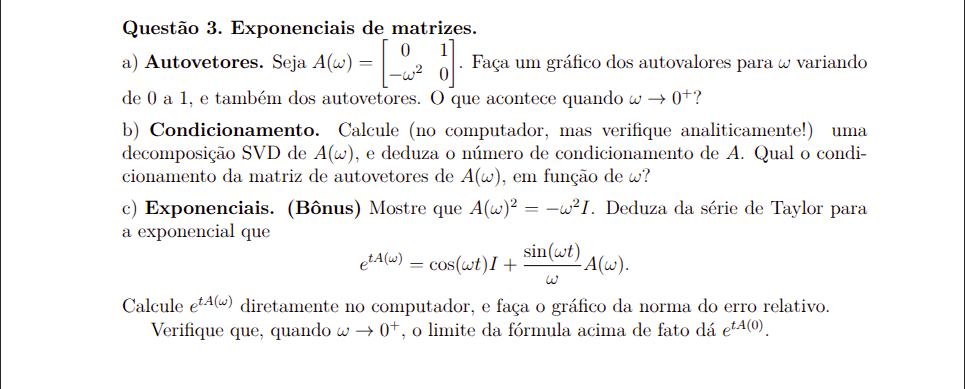